<a href="https://colab.research.google.com/github/jikenta/AI-computer-vision/blob/main/Fire_Smoke_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 Fire & Smoke Detection with AI Segmentation
### A Hands-On Computer Vision Project

---

**What you will learn in this project:**
- What image segmentation is and how it differs from simple detection
- How to use a pre-trained AI model via an API
- How to visualise segmentation masks on images
- How to test the model on your own images

**Tools we are using:**
- [Roboflow](https://roboflow.com) — hosts our pre-trained fire & smoke model
- `inference-sdk` — Roboflow's Python library
- `Pillow` & `matplotlib` — for image handling and visualisation
- `OpenCV` — for drawing masks on images

> **Note:** You do NOT need to train any model. The model is already trained and hosted. You just call it!


---
## 📚 Section 1 — Background: What is Image Segmentation?

There are three levels of computer vision tasks:

| Task | What it does | Output |
|------|-------------|--------|
| **Classification** | "Is there fire in this image?" | A label: `fire` / `no fire` |
| **Detection** | "Where is the fire?" | A bounding box around the fire |
| **Segmentation** | "Exactly which pixels are fire?" | A pixel-level mask |

We are using **instance segmentation** — the model draws a precise outline around every detected fire or smoke region.

This is useful for:
- Calculating the **size** of a fire
- Estimating how fast a fire is **spreading**
- Triggering **automated alerts** in safety systems


---
## ⚙️ Section 2 — Installation

Run this cell once to install all required libraries.

In [ ]:
# Install required packages
!pip install inference-sdk

print("✅ All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: opencv-python
    Found exis

✅ All packages installed successfully!


---
## 🔑 Section 3 — Connect to the Roboflow API

We need to connect to Roboflow where the pre-trained model lives.  
An **API key** is like a password that lets our code use the model.

In [ ]:
from inference_sdk import InferenceHTTPClient

# -----------------------------------------------
# API Configuration
# -----------------------------------------------
API_KEY   = "ty5V2dRxZ8ex89lDu7z6"          # Your Roboflow API key
MODEL_ID  = "fire-and-smoke-segmentation/11" # Pre-trained model ID
API_URL   = "https://serverless.roboflow.com"

# Create the client (this is our connection to the model)
CLIENT = InferenceHTTPClient(
    api_url=API_URL,
    api_key=API_KEY
)

print("✅ Connected to Roboflow API")
print(f"   Model: {MODEL_ID}")

✅ Connected to Roboflow API
   Model: fire-and-smoke-segmentation/11


---
## 🖼️ Section 4 — Load a Test Image

### Option A — Use a sample image from the internet
Run the cell below to download a sample fire image automatically.

### Option B — Upload your own image
Click the **folder icon** on the left sidebar → upload your image → change `IMAGE_PATH` to your filename.

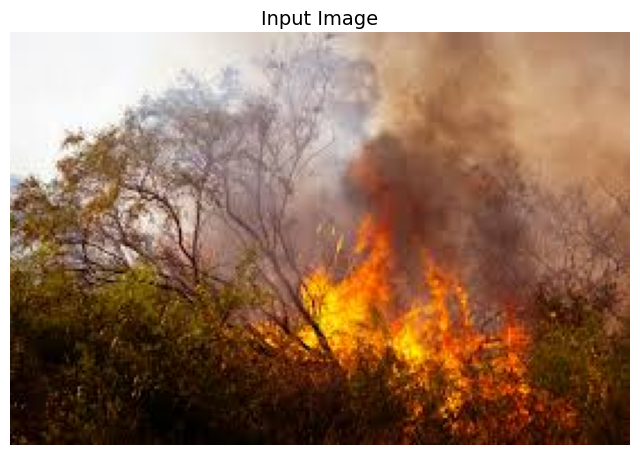

   Image size: 275px × 183px


In [ ]:
import requests
import os
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------------------------
# OPTION A: Download a sample fire image
# -----------------------------------------------
# sample_url = "https://www.google.com/imgres?q=fire%20and%20smoke%20image&imgurl=https%3A%2F%2Fimages.pexels.com%2Fphotos%2F30805406%2Fpexels-photo-30805406.jpeg&imgrefurl=https%3A%2F%2Fwww.pexels.com%2Fsearch%2Ffire%2520and%2520smoke%2F&docid=-AnBGB4qDososM&tbnid=a7h7DRoFA0AI8M&vet=12ahUKEwjMguyu9YuVAxWA4skDHSnvNZQQnPAOegQIRxAB..i&w=5088&h=3392&hcb=2&ved=2ahUKEwjMguyu9YuVAxWA4skDHSnvNZQQnPAOegQIRxAB"
# sample_path = "sample_fire.jpg"

# response = requests.get(sample_url)
# with open(sample_path, "wb") as f:
#     f.write(response.content)

# print(f"✅ Sample image downloaded → '{sample_path}'")

# -----------------------------------------------
# Set which image to analyse
# Change this to your own image path if using Option B
# -----------------------------------------------
IMAGE_PATH = "fire_image.jfif"  # e.g. "my_fire_photo.jpg"

# Preview the image
img = Image.open(IMAGE_PATH)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title("Input Image", fontsize=14)
plt.axis("off")
plt.show()
print(f"   Image size: {img.size[0]}px × {img.size[1]}px")

---
## 🤖 Section 5 — Run the AI Model

This is where the magic happens.  
We send our image to the Roboflow server, the model analyses it, and we get back a **prediction result**.

In [ ]:
print("🔍 Sending image to the model...")

# Run inference (send image → get predictions back)
result = CLIENT.infer(IMAGE_PATH, model_id=MODEL_ID)

print("✅ Prediction received!")
print(f"   Number of objects detected: {len(result.get('predictions', []))}")

🔍 Sending image to the model...
✅ Prediction received!
   Number of objects detected: 3


---
## 🧐 Section 6 — Inspect the Raw Result

Before we visualise anything, let's look at the raw data the model returned.  
Understanding the data structure is an important programming skill!

In [ ]:
import json

# Pretty-print the full result
print("📦 Raw API Response:")
print(json.dumps(result, indent=2))

📦 Raw API Response:
{
  "inference_id": "d9290d8f-5fa6-41d6-9586-f877e1ffccd2",
  "time": 0.04481367184780538,
  "image": {
    "width": 275,
    "height": 183
  },
  "predictions": [
    {
      "x": 210.5,
      "y": 68.5,
      "width": 129.0,
      "height": 137.0,
      "confidence": 0.9315870404243469,
      "class": "smoke",
      "class_id": 1,
      "detection_id": "cac68b1d-9d58-471c-acfd-c4b725fc90b0",
      "points": [
        {
          "x": 152.0,
          "y": 0.0
        },
        {
          "x": 152.0,
          "y": 1.0
        },
        {
          "x": 153.0,
          "y": 2.0
        },
        {
          "x": 153.0,
          "y": 3.0
        },
        {
          "x": 154.0,
          "y": 4.0
        },
        {
          "x": 154.0,
          "y": 5.0
        },
        {
          "x": 155.0,
          "y": 6.0
        },
        {
          "x": 155.0,
          "y": 7.0
        },
        {
          "x": 157.0,
          "y": 9.0
        },
       

In [ ]:
# -----------------------------------------------
# Break down each detected object
# -----------------------------------------------
predictions = result.get("predictions", [])

if not predictions:
    print("⚠️  No fire or smoke detected in this image.")
else:
    print(f"🔥 Found {len(predictions)} object(s):\n")
    for i, pred in enumerate(predictions):
        print(f"  Object {i+1}:")
        print(f"    Class      : {pred.get('class', 'unknown')}")
        print(f"    Confidence : {pred.get('confidence', 0)*100:.1f}%")
        print(f"    Bounding box centre: ({pred.get('x', 0):.0f}, {pred.get('y', 0):.0f})")
        print(f"    Bounding box size  : {pred.get('width', 0):.0f}px × {pred.get('height', 0):.0f}px")
        pts = pred.get("points", [])
        print(f"    Segmentation points: {len(pts)} polygon points")
        print()

🔥 Found 3 object(s):

  Object 1:
    Class      : smoke
    Confidence : 93.2%
    Bounding box centre: (210, 68)
    Bounding box size  : 129px × 137px
    Segmentation points: 117 polygon points

  Object 2:
    Class      : fire
    Confidence : 81.7%
    Bounding box centre: (172, 128)
    Bounding box size  : 129px × 107px
    Segmentation points: 199 polygon points

  Object 3:
    Class      : smoke
    Confidence : 72.3%
    Bounding box centre: (88, 67)
    Bounding box size  : 151px × 132px
    Segmentation points: 211 polygon points



---
## 🎨 Section 7 — Visualise the Segmentation Masks

Now we draw the detected regions on top of the original image.

- 🔴 **Red** = Fire detected
- 🔵 **Blue** = Smoke detected
- Each region shows the **class name** and **confidence score**

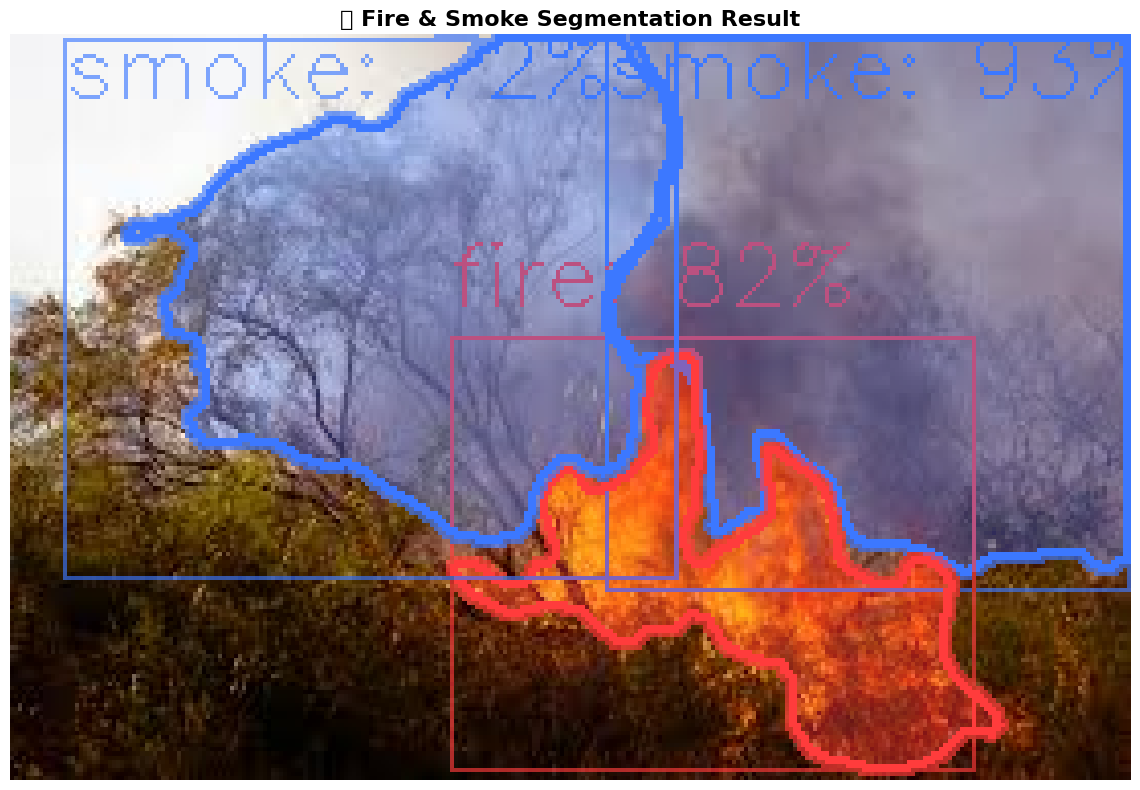

✅ Annotated image saved as 'result_annotated.jpg'


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image with OpenCV (BGR format)
img_cv = cv2.imread(IMAGE_PATH)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)  # Convert to RGB for matplotlib
overlay = img_cv.copy()

# -----------------------------------------------
# Colour map per class
# -----------------------------------------------
CLASS_COLORS = {
    "fire":  (255, 60,  60),   # Red
    "smoke": (60,  120, 255),  # Blue
}
DEFAULT_COLOR = (255, 200, 0)  # Yellow for anything else

predictions = result.get("predictions", [])

if not predictions:
    print("⚠️  No detections to draw — showing original image.")
else:
    for pred in predictions:
        label      = pred.get("class", "unknown")
        confidence = pred.get("confidence", 0)
        points     = pred.get("points", [])
        color      = CLASS_COLORS.get(label.lower(), DEFAULT_COLOR)

        # Draw filled polygon (segmentation mask)
        if points:
            pts_array = np.array([[int(p["x"]), int(p["y"])] for p in points], dtype=np.int32)
            cv2.fillPoly(overlay, [pts_array], color=color)
            cv2.polylines(img_cv, [pts_array], isClosed=True, color=color, thickness=2)

        # Draw bounding box
        x, y = int(pred.get("x", 0)), int(pred.get("y", 0))
        w, h = int(pred.get("width", 0)), int(pred.get("height", 0))
        x1, y1 = x - w // 2, y - h // 2
        x2, y2 = x + w // 2, y + h // 2
        cv2.rectangle(img_cv, (x1, y1), (x2, y2), color, 1)

        # Add label text
        text = f"{label}: {confidence*100:.0f}%"
        cv2.putText(img_cv, text, (x1, max(y1 - 8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 1)

    # Blend the transparent mask overlay
    img_cv = cv2.addWeighted(overlay, 0.35, img_cv, 0.65, 0)

# Display result
plt.figure(figsize=(12, 8))
plt.imshow(img_cv)
plt.title("🔥 Fire & Smoke Segmentation Result", fontsize=16, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("result_annotated.jpg", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Annotated image saved as 'result_annotated.jpg'")

---
## 📊 Section 8 — Summary Statistics

Let's produce a simple summary report of what was detected.

In [ ]:
from collections import Counter

predictions = result.get("predictions", [])

print("=" * 45)
print("       DETECTION SUMMARY REPORT")
print("=" * 45)

if not predictions:
    print("  Status : ✅ No fire or smoke detected")
else:
    class_counts = Counter(p.get("class", "unknown") for p in predictions)
    avg_conf = sum(p.get("confidence", 0) for p in predictions) / len(predictions)

    print(f"  Status : ⚠️  ALERT — Fire/Smoke Detected!")
    print(f"  Total objects found : {len(predictions)}")
    print()
    for cls, count in class_counts.items():
        icon = "🔥" if cls.lower() == "fire" else "💨"
        print(f"  {icon} {cls.capitalize():<10}: {count} region(s)")

    print()
    print(f"  Average confidence  : {avg_conf*100:.1f}%")
    print()
    print("  Individual detections:")
    for i, p in enumerate(predictions):
        print(f"    [{i+1}] {p.get('class','?'):<8} — {p.get('confidence',0)*100:.1f}% confidence")

print("=" * 45)

       DETECTION SUMMARY REPORT
  Status : ⚠️  ALERT — Fire/Smoke Detected!
  Total objects found : 3

  💨 Smoke     : 2 region(s)
  🔥 Fire      : 1 region(s)

  Average confidence  : 82.4%

  Individual detections:
    [1] smoke    — 93.2% confidence
    [2] fire     — 81.7% confidence
    [3] smoke    — 72.3% confidence


---
## 🎥 Section 9 — BONUS: Test on Multiple Images

Upload several images and run the model on all of them in one go.

In [ ]:
from google.colab import files
import io

print("📁 Upload one or more images (jpg, jpeg, png):")
uploaded = files.upload()

📁 Upload one or more images (jpg, jpeg, png):


KeyboardInterrupt: 

In [ ]:
# Run the model on every uploaded image
uploaded_names = list(uploaded.keys())

if not uploaded_names:
    print("No files uploaded.")
else:
    fig, axes = plt.subplots(1, len(uploaded_names), figsize=(7 * len(uploaded_names), 6))
    if len(uploaded_names) == 1:
        axes = [axes]

    for ax, fname in zip(axes, uploaded_names):
        print(f"\n🔍 Analysing: {fname}")
        res = CLIENT.infer(fname, model_id=MODEL_ID)
        preds = res.get("predictions", [])

        img_cv = cv2.imread(fname)
        img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        overlay = img_cv.copy()

        for pred in preds:
            label  = pred.get("class", "unknown")
            conf   = pred.get("confidence", 0)
            points = pred.get("points", [])
            color  = CLASS_COLORS.get(label.lower(), DEFAULT_COLOR)

            if points:
                pts_array = np.array([[int(p["x"]), int(p["y"])] for p in points], np.int32)
                cv2.fillPoly(overlay, [pts_array], color)
                cv2.polylines(img_cv, [pts_array], True, color, 2)

            x, y = int(pred.get("x", 0)), int(pred.get("y", 0))
            w, h = int(pred.get("width", 0)), int(pred.get("height", 0))
            x1, y1 = x - w//2, y - h//2
            cv2.rectangle(img_cv, (x1, y1), (x1+w, y1+h), color, 2)
            cv2.putText(img_cv, f"{label} {conf*100:.0f}%",
                        (x1, max(y1-8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        img_cv = cv2.addWeighted(overlay, 0.35, img_cv, 0.65, 0)
        ax.imshow(img_cv)
        status = f"{len(preds)} detection(s)" if preds else "Nothing detected"
        ax.set_title(f"{fname}\n{status}", fontsize=11)
        ax.axis("off")
        print(f"   → {status}")

    plt.tight_layout()
    plt.show()

---
## 🏆 Section 10 — Student Challenges

Try these tasks to extend the project!

### ⭐ Level 1 — Easy
1. Change the colour of the **smoke mask** from blue to green.
2. Print the **width and height** of each detected object in pixels.
3. Try the model on at least **3 different images** — what do you notice?

### ⭐⭐ Level 2 — Medium
4. Calculate the **percentage of the image** that is covered by fire/smoke.  
   Hint: `area of polygon / (image_width × image_height) × 100`
5. Add a **danger level** based on how much of the image is fire:  
   - < 10% → `LOW`  
   - 10–30% → `MEDIUM`  
   - > 30% → `HIGH`
6. Save a **text file** (`report.txt`) with the detection summary.

### ⭐⭐⭐ Level 3 — Advanced
7. Build a simple **bar chart** using `matplotlib` showing how many fire vs smoke regions were found across multiple images.
8. Modify the code to process a **folder of images** automatically.
9. **Research:** What kind of data was this model trained on? How could you improve it?


In [ ]:
# -----------------------------------------------
# 🧪 YOUR CODE GOES HERE
# Use this cell for the Student Challenges!
# -----------------------------------------------



---
## 📝 Key Concepts Recap

| Term | Meaning |
|------|---------|
| **API** | A way for your code to talk to a remote service (like the Roboflow model) |
| **Inference** | Running a trained model on new data to get predictions |
| **Segmentation** | Identifying the exact pixel boundaries of an object |
| **Confidence score** | How sure the model is about a detection (0–100%) |
| **Polygon points** | The x,y coordinates that define the segmentation shape |
| **Bounding box** | A rectangle drawn around the detected object |
| **Overlay** | Blending a coloured mask on top of the original image |

---

## 🔗 Further Learning

- [Roboflow Universe](https://universe.roboflow.com) — thousands of free pre-trained models
- [Roboflow Docs](https://docs.roboflow.com) — learn to train your own model
- [OpenCV Tutorials](https://docs.opencv.org/4.x/d9/df8/tutorial_root.html) — image processing in Python

---
*Project created for classroom use. Model hosted on Roboflow — `fire-and-smoke-segmentation/11`*